# Aquifer Storage and Recovery: Recovering Freshwater from a Brackish Aquifer

## Learning Objectives
- Model **Aquifer Storage and Recovery (ASR)** at a single well with `gwtransport.radial_asr` -- inject
  treated freshwater into a brackish aquifer in winter, recover it in summer, repeat for several years.
- Use **chloride** as a conservative mixing tracer and read off the **recovery efficiency** (how much of
  the stored freshwater comes back potable) from the exact radial breakthrough.
- See the **buffer effect**: the freshwater left behind each cycle raises the efficiency of the next.
- See how **macrodispersion** (velocity heterogeneity across the well screen) smears the
  fresh--brackish interface and lowers recovery, via a gamma-distributed screen velocity.

## Overview

A coastal utility has surplus treated water in winter and a shortage in summer. Rather than build a
surface reservoir, it stores the surplus *underground*: a single well **injects** freshwater into a
brackish aquifer, the water spreads radially as a growing freshwater bubble, and months later the same
well **extracts** it back. The catch is mixing -- at the moving fresh/brackish interface, dispersion
blends the two waters, so the recovered water gets saltier toward the end of each extraction and not
all of the stored freshwater is usable.

`gwtransport.radial_asr` solves the **exact** radial advection--dispersion for this push--pull
schedule (no finite-volume grid, no numerical dispersion): the volume coordinate
`V(r) = pi b n (r^2 - r_w^2)`, Scheidegger dispersion `D = alpha_L |u|`, Kreft--Zuber flux boundary
conditions, and the exact non-Gaussian breakthrough. Chloride is conservative, so we transport the
deviation from the brackish background and add it back. We will quantify recovery and watch the buffer
build over three yearly cycles.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.radial_asr import gamma_infiltration_to_extraction, infiltration_to_extraction

# --- Site and well ---------------------------------------------------------------------------------
SCREEN_HEIGHT = 20.0          # m, known length of the well screen (fully penetrating)
POROSITY = 0.35               # -
WELL_RADIUS = 0.3             # m
ALPHA_L = 0.5                 # m, longitudinal dispersivity

# --- Water chemistry (chloride, mg/L) --------------------------------------------------------------
C_BRACKISH = 1200.0           # native groundwater
C_FRESH = 50.0                # injected treated water
C_POTABLE = 300.0             # usable-water threshold

GEOM = {
    "porosity": POROSITY,
    "well_radius": WELL_RADIUS,
    "longitudinal_dispersivity": ALPHA_L,
}

## A three-year storage--recovery schedule

Each year: **inject** 1000 m³/day of freshwater for 90 days (a 90,000 m³ bubble), let it **rest** for
60 days, then **recover** 800 m³/day for 120 days. Positive flow is injection, negative is extraction,
zero is rest -- the engine reads the cycles straight off the sign pattern.

In [2]:
def one_cycle():
    inject = [1000.0] * 90      # +1000 m3/day, 90 days  -> 90,000 m3 stored
    rest = [0.0] * 60           # 60 days storage
    recover = [-800.0] * 120    # -800 m3/day, 120 days  -> up to 96,000 m3 pumped
    return inject + rest + recover

n_cycles = 3
flow = np.array(one_cycle() * n_cycles)
tedges = pd.date_range("2021-01-01", periods=len(flow) + 1, freq="D")
t_days = np.arange(len(flow))

# Inject treated freshwater; on extraction/rest bins cin is unused (output is NaN there).
cin = np.where(flow > 0, C_FRESH, C_BRACKISH)

injected_per_cycle = 1000.0 * 90  # m3 of freshwater stored each cycle
print(f"{n_cycles} cycles, {len(flow)} days; {injected_per_cycle:,.0f} m3 injected per cycle")

3 cycles, 810 days; 90,000 m3 injected per cycle


## Recovered chloride: the exact breakthrough

We transport the deviation from the brackish background and read the **extracted** chloride. Early in
each recovery the well returns the stored freshwater (low chloride); as the bubble is drawn down, the
brackish water arrives and the recovered chloride climbs back up.

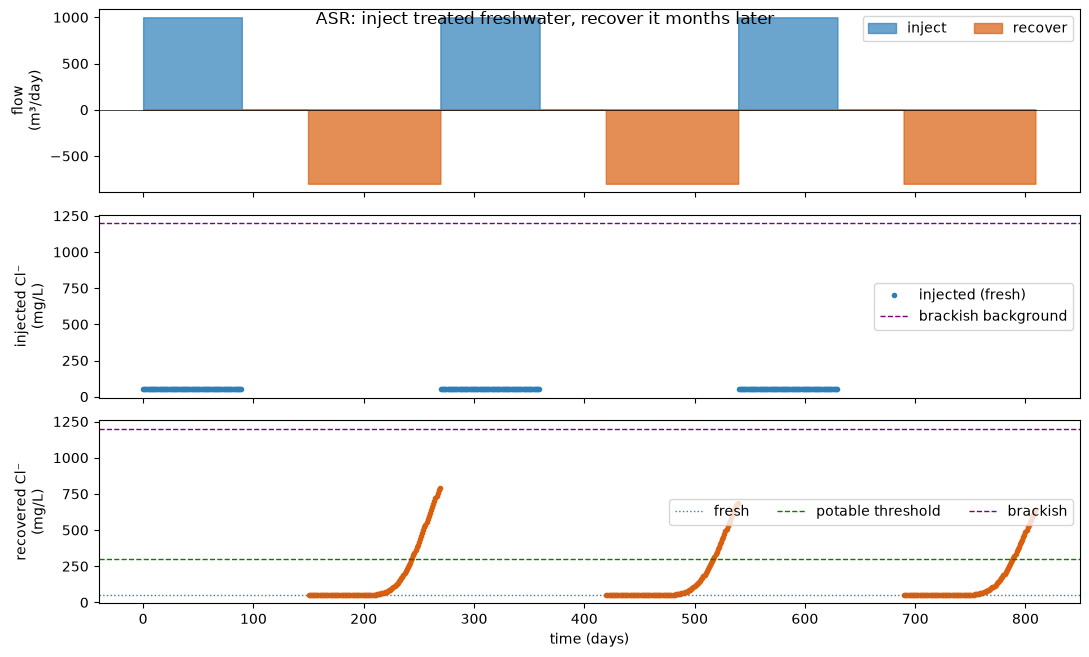

In [3]:
cout = infiltration_to_extraction(
    cin=cin, flow=flow, tedges=tedges, cout_tedges=tedges,
    pore_heights=SCREEN_HEIGHT, background=C_BRACKISH, n_quad=200, **GEOM,
)

inj, ext = flow > 0, flow < 0
fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
ax[0].fill_between(t_days, np.where(flow > 0, flow, 0), step="mid", color="#2c7fb8", alpha=0.7, label="inject")
ax[0].fill_between(t_days, np.where(flow < 0, flow, 0), step="mid", color="#d95f0e", alpha=0.7, label="recover")
ax[0].set_ylabel("flow\n(m³/day)"); ax[0].legend(loc="upper right", ncol=2); ax[0].axhline(0, color="k", lw=0.5)
ax[1].plot(t_days[inj], cin[inj], ".", color="#2c7fb8", label="injected (fresh)")
ax[1].axhline(C_BRACKISH, color="#7a0177", ls="--", lw=1, label="brackish background")
ax[1].set_ylabel("injected Cl⁻\n(mg/L)"); ax[1].legend(loc="center right")
ax[2].plot(t_days[ext], cout[ext], "o", ms=3, color="#d95f0e")
ax[2].axhline(C_FRESH, color="#2c7fb8", ls=":", lw=1, label="fresh")
ax[2].axhline(C_POTABLE, color="green", ls="--", lw=1, label="potable threshold")
ax[2].axhline(C_BRACKISH, color="#7a0177", ls="--", lw=1, label="brackish")
ax[2].set_ylabel("recovered Cl⁻\n(mg/L)"); ax[2].set_xlabel("time (days)"); ax[2].legend(loc="center right", ncol=3)
fig.suptitle("ASR: inject treated freshwater, recover it months later", y=0.93)
fig.tight_layout(); plt.show()

## Recovery efficiency and the buffer effect

The **recovery efficiency** (RE) is the share of injected freshwater that returns below the potable
threshold. With mixing, RE < 100%. But the freshwater that stays behind is not lost -- it forms a
near-well **buffer** that pre-sweetens the brackish water the next cycle must displace, so RE *rises*
cycle over cycle.

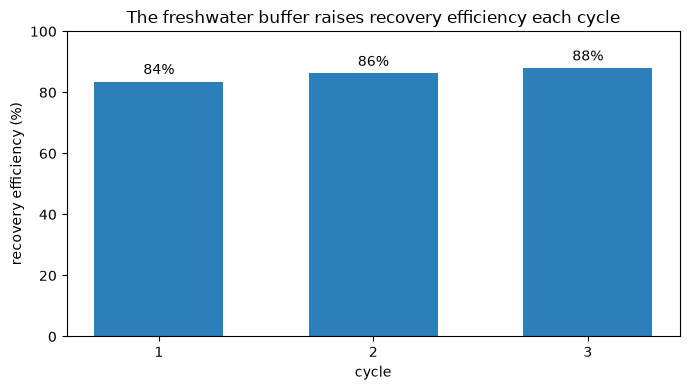

recovery efficiency per cycle: ['84%', '86%', '88%']


In [4]:
cycle_len = len(one_cycle())
dt = np.ones(len(flow))  # 1-day bins
re = []
for k in range(n_cycles):
    sl = slice(k * cycle_len, (k + 1) * cycle_len)
    fseg, cseg = flow[sl], cout[sl]
    eseg = fseg < 0
    usable = np.sum((-fseg[eseg]) * dt[sl][eseg] * (cseg[eseg] < C_POTABLE))  # m3 pumped below threshold
    re.append(usable / injected_per_cycle)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(np.arange(1, n_cycles + 1), 100 * np.array(re), color="#2c7fb8", width=0.6)
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.set_xlabel("cycle"); ax.set_ylabel("recovery efficiency (%)")
ax.set_xticks(np.arange(1, n_cycles + 1)); ax.set_ylim(0, 100)
ax.set_title("The freshwater buffer raises recovery efficiency each cycle")
fig.tight_layout(); plt.show()
print("recovery efficiency per cycle:", [f"{100 * x:.0f}%" for x in re])

## Macrodispersion: velocity heterogeneity across the screen

The screen height is known, but the aquifer is layered -- some depths are more permeable and flow
faster. Does this velocity heterogeneity hurt recovery? Less than intuition suggests. **Pure advective
radial push--pull is reversible**: each layer gives back exactly the water it took, and a fresh bubble
returns in full precisely when the pumped volume equals the injected volume -- *independent of the
layer velocity*. So a spread of layer velocities, on its own, is invisible at the well.

It bites only through **dispersion**. Scheidegger mixing scales with velocity (`D = alpha_L |u|`), so
the fast layers smear their fresh/brackish interface more than the slow ones. The ensemble breakthrough
is the flow-weighted average of these differently-smeared fronts -- still centred on the same pumped
volume, but with a softer shoulder that crosses the potable threshold a little sooner. We introduce it
with `gamma_infiltration_to_extraction`, which distributes the layer velocity across the **fixed**
screen height as a gamma with coefficient of variation `velocity_cv` (0 = homogeneous).

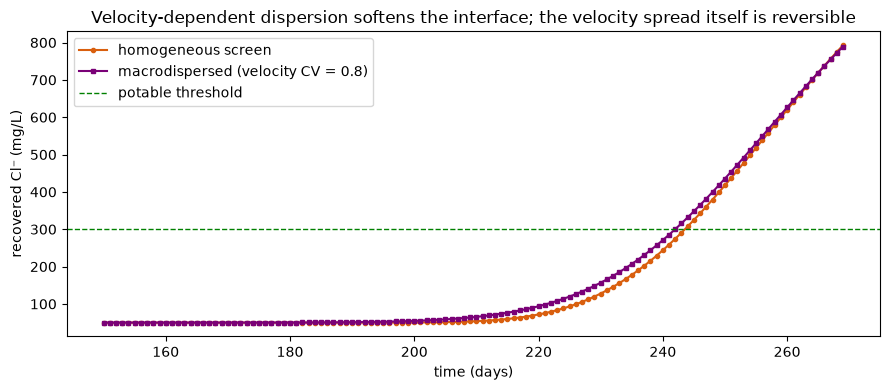

cycle-1 recovery efficiency: homogeneous 84%, macrodispersed 82%


In [5]:
cout_macro = gamma_infiltration_to_extraction(
    cin=cin, flow=flow, tedges=tedges, cout_tedges=tedges,
    screen_height=SCREEN_HEIGHT, velocity_cv=0.8, n_bins=10,
    background=C_BRACKISH, n_quad=200, **GEOM,
)

# focus on the first recovery to see the interface smearing
rec0 = slice(150, 270)  # first extraction window (days 150-269)
td = t_days[rec0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(td, cout[rec0], "o-", ms=3, color="#d95f0e", label="homogeneous screen")
ax.plot(td, cout_macro[rec0], "s-", ms=3, color="#7a0177", label="macrodispersed (velocity CV = 0.8)")
ax.axhline(C_POTABLE, color="green", ls="--", lw=1, label="potable threshold")
ax.set_xlabel("time (days)"); ax.set_ylabel("recovered Cl⁻ (mg/L)")
ax.set_title("Velocity-dependent dispersion softens the interface; the velocity spread itself is reversible")
ax.legend(); fig.tight_layout(); plt.show()

def first_cycle_re(c):
    sl = slice(0, cycle_len); fseg, cseg = flow[sl], c[sl]; e = fseg < 0
    return np.sum((-fseg[e]) * (cseg[e] < C_POTABLE)) / injected_per_cycle

print(f"cycle-1 recovery efficiency: homogeneous {100 * first_cycle_re(cout):.0f}%, "
      f"macrodispersed {100 * first_cycle_re(cout_macro):.0f}%")

## Takeaways

- **ASR is a push--pull problem** the radial engine solves exactly: inject a freshwater bubble, recover
  it later, with the true non-Gaussian fresh/brackish breakthrough -- no grid, no numerical dispersion.
- **Recovery efficiency is set by mixing**: the recovered water sweetens, then salts up as the bubble
  is drawn down; only the water below the potable threshold counts.
- **The buffer compounds**: freshwater left behind each cycle raises the next cycle's efficiency -- the
  physical reason real ASR schemes ramp up over their first few years.
- **Macrodispersion is second-order here**: radial push--pull is *reversible*, so velocity heterogeneity
  across the screen matters only through the velocity-dependent dispersion it amplifies -- it softens the
  interface and trims a couple of points off recovery, well below the buffer effect. The model captures
  it from a single `velocity_cv` on the known screen height.